In [ ]:
# Install the CUDA-enabled versions of torch and torchvision specifically for this session
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# 1. Kaggle Setup

In [1]:
print('Initializingh the project')

Initializingh the project


In [2]:
# Please change these two variables in the bottom of the file `../.env `  to your Kaggle username and key, which you can find in your Kaggle account settings. 
# This will allow you to download the dataset directly from Kaggle using the Kaggle API.

# KAGGLE_USERNAME = 'your_kaggle_username'
# KAGGLE_KEY = 'your_kaggle_key'



# 2. Data Download using kaggle

In [ ]:
%run ..\assignment3\dataset.py


2026-04-26 10:47:22.896 | INFO     | config:<module>:11 - PROJ_ROOT path is: D:\MS_DSI\AI\Assignment3\assignment3


2026-04-26 10:47:22.922 | INFO     | __main__:main:203 - Validating environment configuration ...
2026-04-26 10:47:22.935 | INFO     | __main__:check_env_file:104 - .env file at D:\MS_DSI\AI\Assignment3\assignment3\.env contains required Kaggle credentials.
2026-04-26 10:47:22.936 | INFO     | __main__:main:206 - Setting up project data directories ...
2026-04-26 10:47:22.937 | INFO     | __main__:create_directories:124 - Ensured directory exists: D:\MS_DSI\AI\Assignment3\assignment3\data
2026-04-26 10:47:22.937 | INFO     | __main__:create_directories:124 - Ensured directory exists: D:\MS_DSI\AI\Assignment3\assignment3\data\raw
2026-04-26 10:47:22.938 | INFO     | __main__:create_directories:124 - Ensured directory exists: D:\MS_DSI\AI\Assignment3\assignment3\data\interim
2026-04-26 10:47:22.939 | INFO     | __main__:create_directories:124 - Ensured directory exists: D:\MS_DSI\AI\Assignment3\assignment3\data\processed
2026-04-26 10:47:22.940 | INFO     | __main__:create_directories:12

100%|██████████| 60.6M/60.6M [00:08<00:00, 7.22MB/s]



2026-04-26 10:47:38.201 | SUCCESS  | __main__:download_kaggle_suicide_dataset:194 - Saved crisis dataset to: D:\MS_DSI\AI\Assignment3\assignment3\data\raw\crisis_raw.csv
2026-04-26 10:47:38.202 | SUCCESS  | __main__:main:212 - All raw data ready.


# 3. Cleaning Data and producing these files 

- ../data/processed/counsel_chat_clean.csv   (RAG corpus)
- ../data/processed/crisis_val.csv           (~15% — validation)
- ../data/processed/crisis_train.csv         (~70% — classifier training)
- ../data/processed/crisis_test.csv          (~15% — held-out test)

In [7]:
# ============================================================================
# Data Cleaning & Preparation — Mental Health Chatbot
#
# Paste this entire block into a single Jupyter notebook cell and run it.
# Prerequisite: run `python dataset.py` first to download raw data.
#
# Produces:
#   ../data/processed/counsel_chat_clean.csv   (RAG corpus)
#   ../data/processed/crisis_train.csv         (~70% — classifier training)
#   ../data/processed/crisis_val.csv           (~15% — validation)
#   ../data/processed/crisis_test.csv          (~15% — held-out test)
# ============================================================================

import re
from pathlib import Path

import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# --- Locate project root -----------------------------------------------------
# Walks upward from the notebook's working directory to find the folder that
# contains the `data/` directory (created by dataset.py).
_cwd = Path.cwd().resolve()
PROJ_ROOT = next(
    (p for p in [_cwd, *_cwd.parents] if (p / "data").exists()),
    _cwd,
)
RAW_DATA_DIR       = PROJ_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJ_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 PROJ_ROOT: {PROJ_ROOT}")

# --- Paths & constants -------------------------------------------------------
CRISIS_RAW_PATH    = RAW_DATA_DIR / "crisis_raw.csv"
COUNSEL_RAW_PATH   = RAW_DATA_DIR / "counsel_chat_raw.csv"
COUNSEL_CLEAN_PATH = PROCESSED_DATA_DIR / "counsel_chat_clean.csv"
CRISIS_TRAIN_PATH  = PROCESSED_DATA_DIR / "crisis_train.csv"
CRISIS_VAL_PATH    = PROCESSED_DATA_DIR / "crisis_val.csv"
CRISIS_TEST_PATH   = PROCESSED_DATA_DIR / "crisis_test.csv"

RANDOM_SEED    = 42
MIN_ANSWER_LEN = 50    # Counsel Chat: drop very short therapist answers
MIN_TEXT_LEN   = 20    # Crisis: drop very short posts


# --- Helpers -----------------------------------------------------------------
def clean_text(text):
    """Normalize whitespace, strip URLs, drop non-ASCII characters."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+", " ", text)          # strip URLs
    text = re.sub(r"[^\x00-\x7F]+", " ", text)    # ASCII only
    text = re.sub(r"\s+", " ", text)              # collapse whitespace
    return text.strip()


# --- 1. Counsel Chat → RAG corpus --------------------------------------------
print("\n📚 Processing Counsel Chat ...")
counsel_df = load_dataset("nbertagnolli/counsel-chat", split="train").to_pandas()
counsel_df.to_csv(COUNSEL_RAW_PATH, index=False)

counsel_df["questionText"] = counsel_df["questionText"].apply(clean_text)
counsel_df["answerText"]   = counsel_df["answerText"].apply(clean_text)
counsel_df = counsel_df.dropna(subset=["questionText", "answerText"])
counsel_df = counsel_df[counsel_df["answerText"].str.len() >= MIN_ANSWER_LEN]

counsel_df["document"] = (
    "Question: " + counsel_df["questionText"]
    + "\nAnswer: " + counsel_df["answerText"]
)
counsel_df[["questionText", "answerText", "topic", "document"]].to_csv(
    COUNSEL_CLEAN_PATH, index=False
)
print(f"✅ Counsel Chat: {len(counsel_df):,} rows -> {COUNSEL_CLEAN_PATH.name}")


# --- 2. Crisis dataset → train/val/test --------------------------------------
print("\n🩺 Processing Crisis dataset ...")
if not CRISIS_RAW_PATH.exists():
    raise FileNotFoundError(
        f"crisis_raw.csv not found at {CRISIS_RAW_PATH}. "
        "Run `python dataset.py` first to download it from Kaggle."
    )

crisis_df = pd.read_csv(CRISIS_RAW_PATH)
if "Unnamed: 0" in crisis_df.columns:
    crisis_df = crisis_df.drop(columns=["Unnamed: 0"])

crisis_df = crisis_df[["text", "class"]].copy()
crisis_df.columns = ["text", "label"]
crisis_df["text"] = crisis_df["text"].apply(clean_text)
crisis_df = crisis_df[crisis_df["text"].str.len() >= MIN_TEXT_LEN].dropna()

crisis_df["label_binary"] = crisis_df["label"].map({"suicide": 1, "non-suicide": 0})
crisis_df = crisis_df.dropna(subset=["label_binary"])
crisis_df["label_binary"] = crisis_df["label_binary"].astype(int)

train, temp = train_test_split(
    crisis_df,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=crisis_df["label_binary"],
)
val, test = train_test_split(
    temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp["label_binary"],
)

train.to_csv(CRISIS_TRAIN_PATH, index=False)
val.to_csv(CRISIS_VAL_PATH,   index=False)
test.to_csv(CRISIS_TEST_PATH, index=False)

print(
    f"✅ Crisis splits | Train: {len(train):,} | "
    f"Val: {len(val):,} | Test: {len(test):,}"
)
print("\n🎉 All processed datasets ready.")

📁 PROJ_ROOT: D:\MS_DSI\AI\Assignment3\assignment3

📚 Processing Counsel Chat ...


Repo card metadata block was not found. Setting CardData to empty.


✅ Counsel Chat: 2,744 rows -> counsel_chat_clean.csv

🩺 Processing Crisis dataset ...
✅ Crisis splits | Train: 161,975 | Val: 34,709 | Test: 34,709

🎉 All processed datasets ready.


# 4.1 Training the Model ( Optional : The already trained model is downloadable by runing Cell 4.2 instead )

In [ ]:
# ============================================================================
# Crisis Classifier Training — DistilBERT fine-tuning
#
# Paste this entire block into a single Jupyter notebook cell and run it.
# Prerequisite: data/processed/crisis_train.csv and crisis_val.csv exist
#               (run the cleaning cell or `python clean.py` first).
#
# Saves the final model to: <PROJ_ROOT>/models/crisis_classifier/
# ============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

# --- Locate project root -----------------------------------------------------
_cwd = Path.cwd().resolve()
PROJ_ROOT = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / "data").exists() or (p / ".env").exists()),
    _cwd,
)
TRAIN_PATH = PROJ_ROOT / "data" / "processed" / "crisis_train.csv"
VAL_PATH   = PROJ_ROOT / "data" / "processed" / "crisis_val.csv"
MODEL_DIR  = PROJ_ROOT / "models" / "crisis_classifier"

# --- Hyperparameters ---------------------------------------------------------
MODEL_NAME  = "distilbert-base-uncased"
MAX_LENGTH  = 128
SEED        = 42

SAMPLE      = False       # True  = quick smoke run (10k rows)
                         # False = full dataset
SAMPLE_SIZE = 10_000
VAL_SAMPLE  = 2_000

NUM_EPOCHS       = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE  = 32

# --- Device ------------------------------------------------------------------
if torch.cuda.is_available():
    DEVICE = "cuda"
    print("✅ Using CUDA GPU")
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print("✅ Using Apple Silicon MPS")
else:
    DEVICE = "cpu"
    print("⚠️  Using CPU — full training will be very slow. Consider Colab.")

print(f"📁 PROJ_ROOT: {PROJ_ROOT}")
print(f"📂 Output:    {MODEL_DIR}")

# --- Load & sample data ------------------------------------------------------
if not TRAIN_PATH.exists() or not VAL_PATH.exists():
    raise FileNotFoundError(
        f"Crisis splits not found in {TRAIN_PATH.parent}. "
        "Run the cleaning cell (or clean.py) first."
    )

train_df = pd.read_csv(TRAIN_PATH)[["text", "label_binary"]].dropna()
val_df   = pd.read_csv(VAL_PATH)[["text", "label_binary"]].dropna()

if SAMPLE:
    train_df = train_df.sample(n=min(SAMPLE_SIZE, len(train_df)), random_state=SEED)
    val_df   = val_df.sample(  n=min(VAL_SAMPLE,  len(val_df)),   random_state=SEED)
    print(f"⚠️  SAMPLE MODE — Train: {len(train_df):,} | Val: {len(val_df):,}")
else:
    print(f"✅ FULL MODE — Train: {len(train_df):,} | Val: {len(val_df):,}")

# HF Trainer expects the label column to be called 'labels'
train_df = train_df.rename(columns={"label_binary": "labels"})
val_df   = val_df.rename(columns={"label_binary": "labels"})


# --- Tokenize ----------------------------------------------------------------
print("\n🔤 Loading tokenizer ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def _tok_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

print("🔤 Tokenising ...")
train_ds = Dataset.from_pandas(train_df, preserve_index=False).map(_tok_batch, batched=True)
val_ds   = Dataset.from_pandas(val_df,   preserve_index=False).map(_tok_batch, batched=True)


# --- Model -------------------------------------------------------------------
print(f"\n🤖 Loading base model '{MODEL_NAME}' ...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


# --- Metrics -----------------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall":    recall_score(labels, preds),
    }


# --- Training ----------------------------------------------------------------
MODEL_DIR.mkdir(parents=True, exist_ok=True)

args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    seed=SEED,
    report_to="none",   # disable wandb / tensorboard auto-init
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("\n🏋️  Training started ...")
trainer.train()

print(f"\n💾 Saving final model to {MODEL_DIR} ...")
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
print("✅ Training complete.")

# 4.2 Downloading the previously trained model for the project 

In [2]:
print('Starting the model download')
# ============================================================================
# Download fine-tuned Crisis Classifier model from Google Drive
#
# Paste this entire block into a single Jupyter notebook cell and run it.
# Requires: pip install gdown
#
# Produces:
#   ../models/crisis_classifier/
#       ├── config.json
#       ├── model.safetensors
#       ├── tokenizer.json
#       ├── tokenizer_config.json
#       └── training_args.bin
# ============================================================================

from pathlib import Path

import gdown

# --- Locate project root -----------------------------------------------------
# Walks upward from the notebook's working directory until it finds a folder
# that has either `data/` or `.env` in it (i.e. the project root).
_cwd = Path.cwd().resolve()
PROJ_ROOT = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / "data").exists() or (p / ".env").exists()),
    _cwd,
)
CRISIS_MODEL_DIR = PROJ_ROOT / "models" / "crisis_classifier"
CRISIS_MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Model dir: {CRISIS_MODEL_DIR}")

# --- Google Drive file IDs ---------------------------------------------------
FILES = {
    "config.json":           "16tvn1X7CgSvMNWRQxpdHNqyBOfH_YwXD",
    "model.safetensors":     "1kFfjErvjm2EfJW5u2DMYxXwWoDnFmQaG",
    "tokenizer.json":        "1IzTCTPK7ElMYSSj5Vl5x57M1LTJ3h3VB",
    "tokenizer_config.json": "1IHtzJajxLyd8sEJXE7_mENPUC-LZHj-j",
    "training_args.bin":     "1qHRNifMtwQs5ebq_mDAj3xkIuiof08kF",
}

# --- Download ----------------------------------------------------------------
downloaded, skipped = 0, 0
for filename, file_id in FILES.items():
    out_path = CRISIS_MODEL_DIR / filename
    if out_path.exists():
        print(f"⏭️  {filename} already exists, skipping.")
        skipped += 1
        continue
    print(f"⬇️  Downloading {filename} ...")
    gdown.download(id=file_id, output=str(out_path), quiet=False)
    downloaded += 1

print(
    f"\n✅ Crisis classifier ready | Downloaded: {downloaded} | "
    f"Skipped: {skipped} | Location: {CRISIS_MODEL_DIR}"
)

Starting the model download
📁 Model dir: D:\MS_DSI\AI\Assignment3\assignment3\models\crisis_classifier
⬇️  Downloading config.json ...


Downloading...
From: https://drive.google.com/uc?id=16tvn1X7CgSvMNWRQxpdHNqyBOfH_YwXD
To: D:\MS_DSI\AI\Assignment3\assignment3\models\crisis_classifier\config.json
100%|██████████| 663/663 [00:00<00:00, 288kB/s]


⬇️  Downloading model.safetensors ...


Downloading...
From (original): https://drive.google.com/uc?id=1kFfjErvjm2EfJW5u2DMYxXwWoDnFmQaG
From (redirected): https://drive.google.com/uc?id=1kFfjErvjm2EfJW5u2DMYxXwWoDnFmQaG&confirm=t&uuid=75455f3b-79e9-4201-8f1a-38eb82b6b29b
To: D:\MS_DSI\AI\Assignment3\assignment3\models\crisis_classifier\model.safetensors
100%|██████████| 268M/268M [00:35<00:00, 7.52MB/s] 


⬇️  Downloading tokenizer.json ...


...

⬇️  Downloading tokenizer_config.json ...


Downloading...
From: https://drive.google.com/uc?id=1IHtzJajxLyd8sEJXE7_mENPUC-LZHj-j
To: D:\MS_DSI\AI\Assignment3\assignment3\models\crisis_classifier\tokenizer_config.json
100%|██████████| 328/328 [00:00<?, ?B/s] 


⬇️  Downloading training_args.bin ...


Downloading...
From: https://drive.google.com/uc?id=1qHRNifMtwQs5ebq_mDAj3xkIuiof08kF
To: D:\MS_DSI\AI\Assignment3\assignment3\models\crisis_classifier\training_args.bin
100%|██████████| 5.20k/5.20k [00:00<?, ?B/s]


✅ Crisis classifier ready | Downloaded: 5 | Skipped: 0 | Location: D:\MS_DSI\AI\Assignment3\assignment3\models\crisis_classifier


# 5. Test The predictions 

In [ ]:
print('hello')

Starting the dataset setup


In [4]:
# ============================================================================
# Crisis Classifier — Inference Smoke Test
#
# Paste this entire block into a single Jupyter notebook cell and run it.
# Prerequisite: model files in <PROJ_ROOT>/models/crisis_classifier/
#               (run download_model.py / its notebook cell first).
# ============================================================================

from pathlib import Path

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# --- Locate project root -----------------------------------------------------
# Walks upward from the notebook's working directory until it finds a folder
# that has either `data/` or `.env` in it.
_cwd = Path.cwd().resolve()
PROJ_ROOT = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / "data").exists() or (p / ".env").exists()),
    _cwd,
)
CRISIS_MODEL_DIR = PROJ_ROOT / "models" / "crisis_classifier"
MAX_LENGTH       = 128
THRESHOLD        = 0.7
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

print(f"📁 Model dir: {CRISIS_MODEL_DIR}")
print(f"🖥️  Device:    {DEVICE}")

# --- Load model --------------------------------------------------------------
if not CRISIS_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"Model not found at {CRISIS_MODEL_DIR}. "
        "Run the download_model notebook cell first to fetch it from Google Drive."
    )

# AutoTokenizer / AutoModel pick the right class automatically.
# (The model dir ships tokenizer.json — fast tokenizer — but no vocab.txt,
#  so the slow DistilBertTokenizer would fail to load.)
tokenizer = AutoTokenizer.from_pretrained(str(CRISIS_MODEL_DIR))
model     = AutoModelForSequenceClassification.from_pretrained(str(CRISIS_MODEL_DIR))
model.to(DEVICE).eval()
print("✅ Model loaded\n")


# --- Inference ---------------------------------------------------------------
def is_crisis(text, threshold=THRESHOLD):
    """Score a single message for crisis content."""
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=1)
    crisis_prob = probs[0][1].item()

    return {
        "is_crisis":  crisis_prob >= threshold,
        "confidence": round(crisis_prob, 4),
        "label":      "crisis" if crisis_prob >= threshold else "non-crisis",
        "method":     "model",
    }


# --- Test it -----------------------------------------------------------------
test_messages = [
    "I have been feeling really anxious lately and don't know what to do 😃",
    "I want to kill myself, I can't take this anymore 😃",
    "Can you help me with some breathing exercises?",
    "I've been having dark thoughts and feel like ending it all",
    "I'm struggling with my relationship and feeling lost",
]

print("Testing messages:")
print("-" * 60)
for msg in test_messages:
    result = is_crisis(msg)
    flag = "🚨" if result["is_crisis"] else "✅"
    print(
        f"{flag} [{result['label'].upper()}] "
        f"confidence: {result['confidence']:.2%}"
    )
    print(f"   {msg[:80]}")
    print()

📁 Model dir: D:\MS_DSI\AI\Assignment3\assignment3\models\crisis_classifier
🖥️  Device:    cpu


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1103.45it/s]


✅ Model loaded

Testing messages:
------------------------------------------------------------
✅ [NON-CRISIS] confidence: 0.07%
   I have been feeling really anxious lately and don't know what to do 😃

🚨 [CRISIS] confidence: 99.30%
   I want to kill myself, I can't take this anymore 😃

✅ [NON-CRISIS] confidence: 0.62%
   Can you help me with some breathing exercises?

✅ [NON-CRISIS] confidence: 4.21%
   I've been having dark thoughts and feel like ending it all

✅ [NON-CRISIS] confidence: 0.21%
   I'm struggling with my relationship and feeling lost



# 6. Evaluate the Predictions

📁 PROJ_ROOT: D:\MS_DSI\AI\Assignment3\assignment3
🖥️  Device:    cuda

📊 Loading test data ...
✅ Test set: 34,709 rows

🤖 Loading model from D:\MS_DSI\AI\Assignment3\assignment3\models\crisis_classifier ...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3306.61it/s]


🔤 Tokenising ...

🔮 Running predictions ...
  Batch 0/1085 ...
  Batch 10/1085 ...
  Batch 20/1085 ...
  Batch 30/1085 ...
  Batch 40/1085 ...
  Batch 50/1085 ...
  Batch 60/1085 ...
  Batch 70/1085 ...
  Batch 80/1085 ...
  Batch 90/1085 ...
  Batch 100/1085 ...
  Batch 110/1085 ...
  Batch 120/1085 ...
  Batch 130/1085 ...
  Batch 140/1085 ...
  Batch 150/1085 ...
  Batch 160/1085 ...
  Batch 170/1085 ...
  Batch 180/1085 ...
  Batch 190/1085 ...
  Batch 200/1085 ...
  Batch 210/1085 ...
  Batch 220/1085 ...
  Batch 230/1085 ...
  Batch 240/1085 ...
  Batch 250/1085 ...
  Batch 260/1085 ...
  Batch 270/1085 ...
  Batch 280/1085 ...
  Batch 290/1085 ...
  Batch 300/1085 ...
  Batch 310/1085 ...
  Batch 320/1085 ...
  Batch 330/1085 ...
  Batch 340/1085 ...
  Batch 350/1085 ...
  Batch 360/1085 ...
  Batch 370/1085 ...
  Batch 380/1085 ...
  Batch 390/1085 ...
  Batch 400/1085 ...
  Batch 410/1085 ...
  Batch 420/1085 ...
  Batch 430/1085 ...
  Batch 440/1085 ...
  Batch 450/1085 ...
 

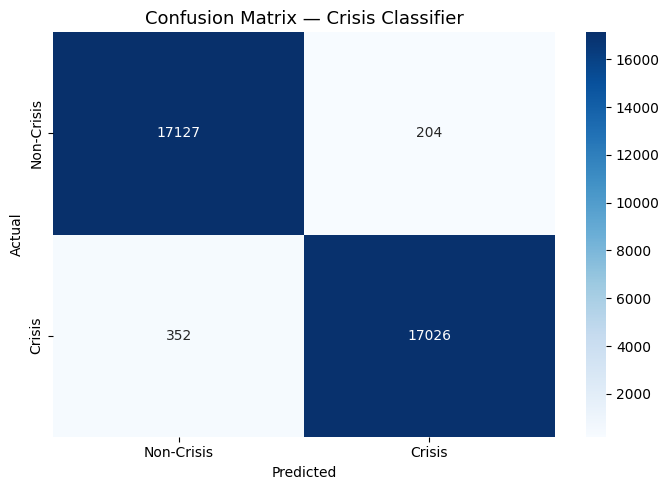


✅ Confusion matrix saved to D:\MS_DSI\AI\Assignment3\assignment3\reports\figures\confusion_matrix.png
✅ Results saved to D:\MS_DSI\AI\Assignment3\assignment3\reports\crisis_classifier_results.csv


In [5]:
# ============================================================================
# Crisis Classifier Evaluation — held-out test set
#
# Paste this entire block into a single Jupyter notebook cell and run it.
# Prerequisites:
#   - Trained model in <PROJ_ROOT>/models/crisis_classifier/
#   - <PROJ_ROOT>/data/processed/crisis_test.csv
#
# Outputs:
#   - reports/crisis_classifier_results.csv
#   - reports/figures/confusion_matrix.png
# ============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# --- Locate project root -----------------------------------------------------
_cwd = Path.cwd().resolve()
PROJ_ROOT = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / "data").exists() or (p / ".env").exists()),
    _cwd,
)
MODEL_DIR    = PROJ_ROOT / "models" / "crisis_classifier"
TEST_PATH    = PROJ_ROOT / "data" / "processed" / "crisis_test.csv"
REPORTS_DIR  = PROJ_ROOT / "reports"
FIGURES_DIR  = REPORTS_DIR / "figures"
CM_FIG_PATH  = FIGURES_DIR / "confusion_matrix.png"
RESULTS_PATH = REPORTS_DIR / "crisis_classifier_results.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 128
BATCH_SIZE = 32
THRESHOLD  = 0.7
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

print(f"📁 PROJ_ROOT: {PROJ_ROOT}")
print(f"🖥️  Device:    {DEVICE}")


# --- Dataset class -----------------------------------------------------------
class CrisisDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "label":          self.labels[idx],
        }


# --- Load test data ----------------------------------------------------------
if not TEST_PATH.exists():
    raise FileNotFoundError(
        f"Test split not found at {TEST_PATH}. "
        "Run the cleaning cell (or clean.py) first."
    )

print("\n📊 Loading test data ...")
df = pd.read_csv(TEST_PATH)[["text", "label_binary"]].dropna()
print(f"✅ Test set: {len(df):,} rows")


# --- Load model --------------------------------------------------------------
if not MODEL_DIR.exists():
    raise FileNotFoundError(
        f"Model not found at {MODEL_DIR}. "
        "Run the download_model cell or train cell first."
    )

print(f"\n🤖 Loading model from {MODEL_DIR} ...")
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))
model     = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR))
model.to(DEVICE).eval()


# --- Tokenize & build loader -------------------------------------------------
print("🔤 Tokenising ...")
dataset = CrisisDataset(
    df["text"].tolist(),
    df["label_binary"].tolist(),
    tokenizer,
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE)


# --- Predict -----------------------------------------------------------------
print("\n🔮 Running predictions ...")
all_preds, all_labels = [], []

with torch.no_grad():
    for i, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).logits
        probs = torch.softmax(logits, dim=1)
        preds = (probs[:, 1] >= THRESHOLD).int().cpu().tolist()

        all_preds.extend(preds)
        all_labels.extend(batch["label"].tolist())

        if i % 10 == 0:
            print(f"  Batch {i}/{len(loader)} ...")


# --- Metrics -----------------------------------------------------------------
acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec  = recall_score(all_labels, all_preds)
cm   = confusion_matrix(all_labels, all_preds)

print("\n" + "=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy:  {acc:.4f} ({acc * 100:.2f}%)")
print(f"F1 Score:  {f1:.4f} ({f1 * 100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec * 100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec * 100:.2f}%)")
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Non-Crisis", "Crisis"],
))


# --- Confusion matrix plot ---------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Non-Crisis", "Crisis"],
    yticklabels=["Non-Crisis", "Crisis"],
    ax=ax,
)
ax.set_title("Confusion Matrix — Crisis Classifier", fontsize=13)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(CM_FIG_PATH, dpi=150)
plt.show()
print(f"\n✅ Confusion matrix saved to {CM_FIG_PATH}")


# --- Save metrics CSV --------------------------------------------------------
results = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "Precision", "Recall"],
    "Score":  [acc, f1, prec, rec],
})
results.to_csv(RESULTS_PATH, index=False)
print(f"✅ Results saved to {RESULTS_PATH}")